In [1]:
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
print("Setup Complete")

Setup Complete


In [2]:
df = pd.read_csv(r"C:\users\andre\hospital_patients_real_world.csv")
print(df.head())

    PatientID   Age   Gender              Diagnosis AdmissionDate  \
0  PN-2021066   7.0    Other  Myocardial Infarction    2024-03-23   
1  PN-4606019  36.0    Other              Pneumonia    2024-08-01   
2  PN-2594016  70.0    Other              Influenza    2024-11-16   
3  PN-6906914  90.0  Unknown       Acute Bronchitis    2025-07-05   
4  PN-4656204   0.0   Female        Type 2 Diabetes    2023-08-30   

  DischargeDate HospitalID  
0    2024-03-29    HOSP-65  
1    2024-08-07    HOSP-79  
2    2024-11-23    HOSP-27  
3    2025-07-10    HOSP-64  
4    2023-08-31    HOSP-31  


In [3]:
print(df.isna().sum())
print()
print(df.dtypes)
print()
print(df.info())
print()
print(df.duplicated().sum())

PatientID          0
Age              350
Gender           350
Diagnosis        350
AdmissionDate      0
DischargeDate      0
HospitalID         0
dtype: int64

PatientID            str
Age              float64
Gender               str
Diagnosis            str
AdmissionDate        str
DischargeDate        str
HospitalID           str
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PatientID      5000 non-null   str    
 1   Age            4650 non-null   float64
 2   Gender         4650 non-null   str    
 3   Diagnosis      4650 non-null   str    
 4   AdmissionDate  5000 non-null   str    
 5   DischargeDate  5000 non-null   str    
 6   HospitalID     5000 non-null   str    
dtypes: float64(1), str(6)
memory usage: 273.6 KB
None

0


In [4]:
df = df.dropna(subset=['Age', 'Gender', 'Diagnosis'])
print(df.isna().sum())

PatientID        0
Age              0
Gender           0
Diagnosis        0
AdmissionDate    0
DischargeDate    0
HospitalID       0
dtype: int64


In [5]:

df['Diagnosis'] = df['Diagnosis'].str.lower().str.title()
print(df['Diagnosis'].unique())

<StringArray>
[  'Myocardial Infarction',               'Pneumonia',
               'Influenza',        'Acute Bronchitis',
         'Type 2 Diabetes',         'Gastroenteritis',
 'Urinary Tract Infection',          'Diverticulitis',
          'Cholelithiasis',            'Hypertension',
  'Chronic Kidney Disease',     'Atrial Fibrillation',
                  'Asthma',          'Osteoarthritis']
Length: 14, dtype: str


In [6]:
#converting date times from strings to date times
df['AdmissionDate'] = pd.to_datetime(df['AdmissionDate'], errors='coerce')
df['DischargeDate'] = pd.to_datetime(df['DischargeDate'], errors='coerce')
print(df.dtypes)

PatientID                   str
Age                     float64
Gender                      str
Diagnosis                   str
AdmissionDate    datetime64[us]
DischargeDate    datetime64[us]
HospitalID                  str
dtype: object


## Ranking Diagnoses by Frequency

The diagnoses are sorted in descending order based on their frequency. This allows us to clearly identify the most commonly occurring diagnoses within the filtered group.

In [22]:
#Which diagnosis is most common overall?
common_diagnosis = df.groupby('Diagnosis').agg(
    Common = ('Diagnosis', 'count')
)


common_sorted = common_diagnosis.sort_values(by='Common', ascending=False).reset_index()
common_sorted


,Diagnosis,Common
0,Urinary Tract Infection,310
1,Cholelithiasis,305
2,Acute Bronchitis,301
3,Asthma,300
4,Diverticulitis,296
5,Atrial Fibrillation,295
6,Osteoarthritis,291
7,Chronic Kidney Disease,276
8,Hypertension,276
9,Gastroenteritis,275


## Filtering Patients Aged 0–12 (Children)

We subset the dataset to include only patients aged 13 or younger. This allows us to analyze diagnosis patterns within the pediatric group.

It is important to note that this dataset does not appear to follow realistic medical distributions, so results should be interpreted as patterns within the dataset rather than real-world conclusions.

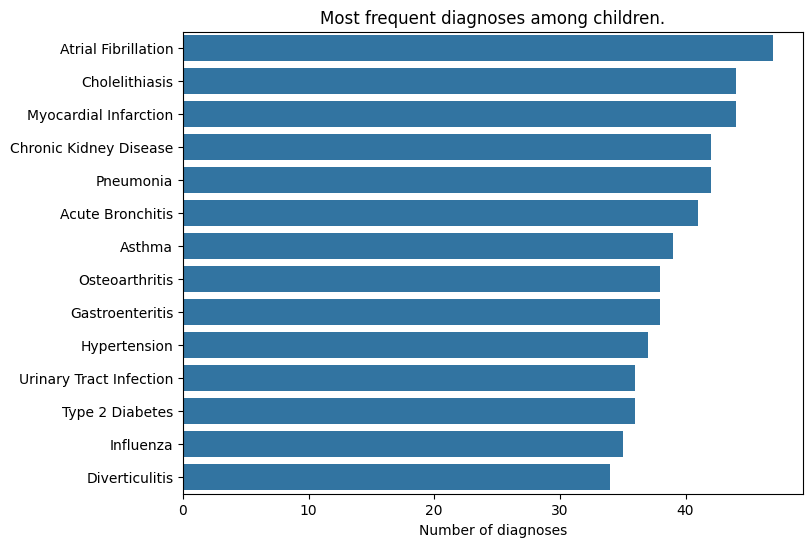

In [39]:

df_children = df[df['Age'] <= 12]
children_diagnosis = df_children.groupby('Diagnosis').agg(
    Common = ('Diagnosis', 'count')
)
common_children = children_diagnosis.sort_values(by='Common', ascending=False).reset_index()
common_children
fig, ax = plt.subplots(figsize = (8, 6))
sns.barplot(data=common_children, x = 'Common', y = 'Diagnosis', ax=ax)
plt.title('Most frequent diagnoses among children.')
plt.ylabel("")
plt.xlabel("Number of diagnoses")
plt.show()




## Most Frequent Diagnoses Among Children

We group the filtered dataset by diagnosis and count the number of occurrences for each category. This helps identify which diagnoses appear most frequently within the 0–13 age group.

The counts reflect how often each diagnosis appears in the dataset, not the actual prevalence of diseases in real-world pediatric populations.

##

## Filtering Patients Aged 13–19 (Teenagers)

We isolate patients within the 13–19 age range to analyze diagnosis patterns for teenagers.

This segmentation enables comparison between different age groups, although the dataset does not guarantee realistic medical relationships between age and diagnosis.

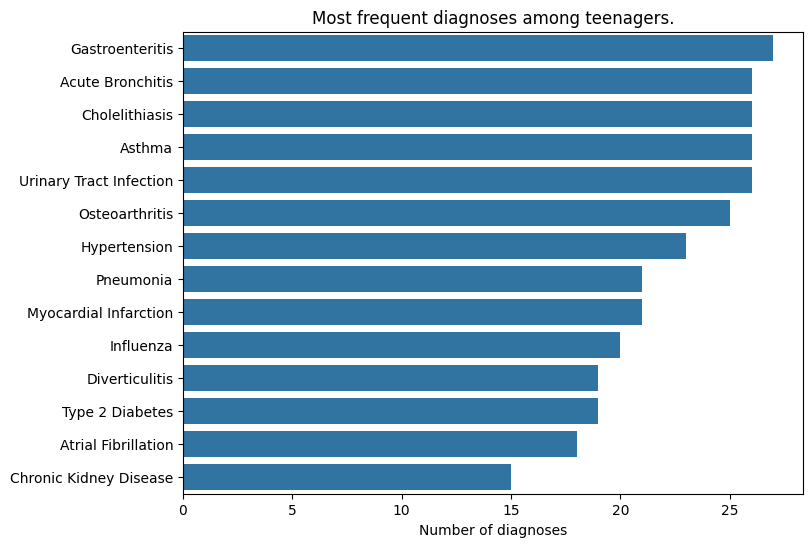

In [ ]:
df_teenagers = df[(df['Age'] >= 13) & (df['Age'] <= 19)]
teenagers_diagnosis = df_teenagers.groupby('Diagnosis').agg(
    Common = ('Diagnosis', 'count')
)
common_teenagers = teenagers_diagnosis.sort_values(by="Common", ascending=False).reset_index()
common_teenagers
fig, ax = fig, ax = plt.subplots(figsize = (8, 6))
sns.barplot(data=common_teenagers, x = 'Common', y = 'Diagnosis', ax=ax)
plt.title('Most frequent diagnoses among teenagers.')
plt.ylabel("")
plt.xlabel("Number of diagnoses")
plt.show()



## Most Frequent Diagnoses Among Teenagers

We group the teenage subset by diagnosis and compute the frequency of each category.

This provides insight into which diagnoses are most commonly recorded for patients aged 13–19 within this dataset.

##

## Filtering Patients Aged 20-34 (Young Adults)

We subset the dataset to include patients classified as young adults. This group represents individuals transitioning from adolescence into adulthood.

Segmenting this category allows us to analyze how diagnosis distributions differ from both teenage and fully adult populations within the dataset.

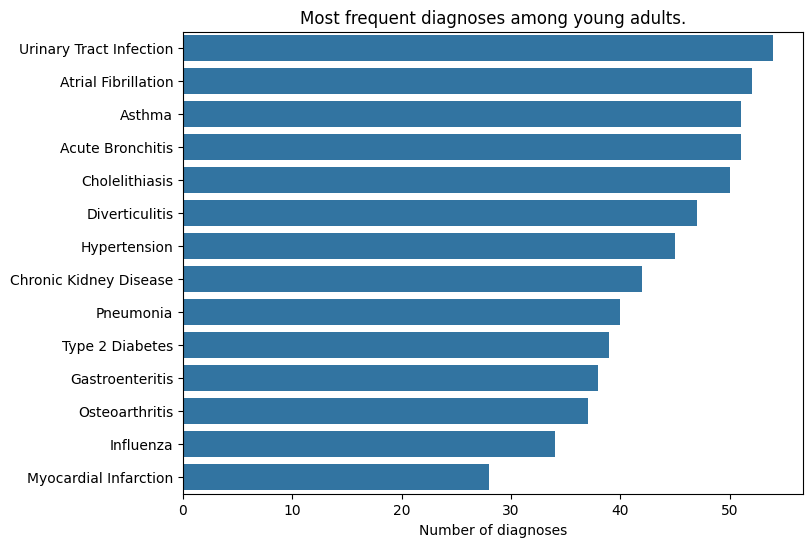

In [42]:
df_young_adults = df[(df['Age'] >= 20) & (df['Age'] <= 34)]
young_adults_diagnosis = df_young_adults.groupby('Diagnosis').agg(
    Common = ('Diagnosis', 'count')
)
common_young_adults = young_adults_diagnosis.sort_values(by='Common', ascending=False).reset_index()
common_young_adults
fig, ax = fig, ax = plt.subplots(figsize = (8, 6))
sns.barplot(data=common_young_adults, x = 'Common', y = 'Diagnosis', ax=ax)
plt.title('Most frequent diagnoses among young adults.')
plt.ylabel("")
plt.xlabel("Number of diagnoses")
plt.show()


## Most Frequent Diagnoses Among Young Adults

We group the young adult subset by diagnosis and calculate the frequency of each condition.

This provides an overview of which diagnoses are most commonly recorded for individuals in this age group within the dataset.

##

## Filtering Patients Aged 35-64 (Adults)

We isolate patients categorized as adults to examine diagnosis patterns within this broader and typically more medically diverse group.

This segmentation enables comparison with younger populations and helps identify shifts in diagnosis distribution across age ranges.

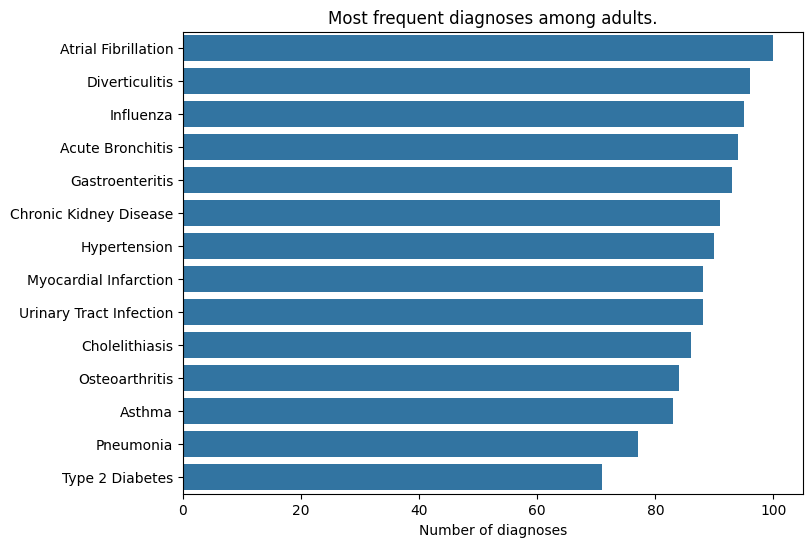

In [43]:
df_adults = df[(df['Age'] >= 35) & (df['Age'] <= 64)]
adults_diagnosis = df_adults.groupby('Diagnosis').agg(
    Common = ('Diagnosis', 'count')
)
common_adults = adults_diagnosis.sort_values(by="Common", ascending=False).reset_index()
common_adults
fig, ax = fig, ax = plt.subplots(figsize = (8, 6))
sns.barplot(data=common_adults, x = 'Common', y = 'Diagnosis', ax=ax)
plt.title('Most frequent diagnoses among adults.')
plt.ylabel("")
plt.xlabel("Number of diagnoses")
plt.show()


## Visualization of Diagnosis Distribution in Adults

A bar chart is used to display the distribution of diagnoses among adult patients.

This visualization provides a clear ranking of conditions based on their frequency within the dataset.

##

## Filtering Patients Aged 65-99 (Seniors)

We extract patients classified as seniors to analyze diagnosis patterns in older age groups.

This category is important for understanding how diagnosis distributions change with age within the dataset.

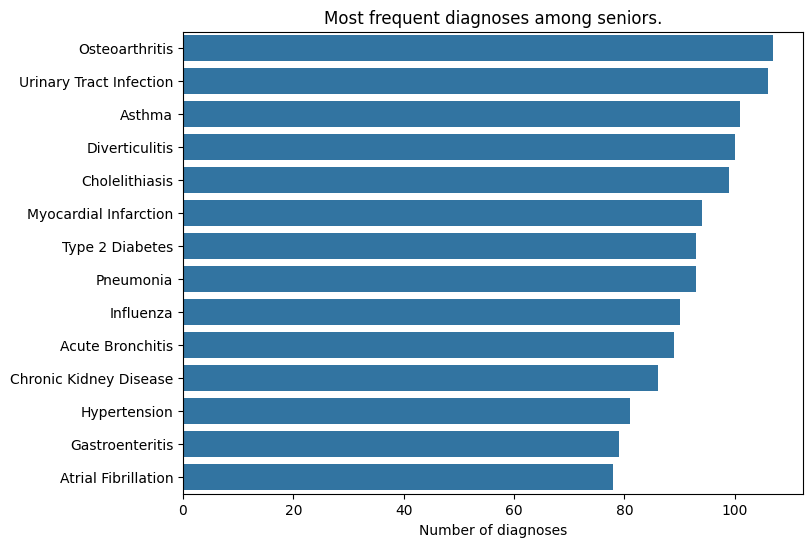

In [44]:
df_seniors = df[(df['Age'] >= 65) & (df['Age'] <= 99)]
seniors_diagnosis = df_seniors.groupby('Diagnosis').agg(
    Common = ('Diagnosis', 'count')
)
common_seniors = seniors_diagnosis.sort_values(by="Common", ascending=False).reset_index()
common_seniors
fig, ax = fig, ax = plt.subplots(figsize = (8, 6))
sns.barplot(data=common_seniors, x = 'Common', y = 'Diagnosis', ax=ax)
plt.title('Most frequent diagnoses among seniors.')
plt.ylabel("")
plt.xlabel("Number of diagnoses")
plt.show()


## Most Frequent Diagnoses Among Seniors

We group the senior subset by diagnosis and compute the frequency of each condition.

This reveals which diagnoses are most commonly recorded among older patients in the dataset.

##


## Calculating Patient Stay Duration

We compute the duration of each patient's hospital stay by subtracting the admission date from the discharge date.

Only records with positive durations are retained to ensure data validity and to exclude erroneous or inconsistent entries.

<Axes: xlabel='Time', ylabel='Diagnosis'>

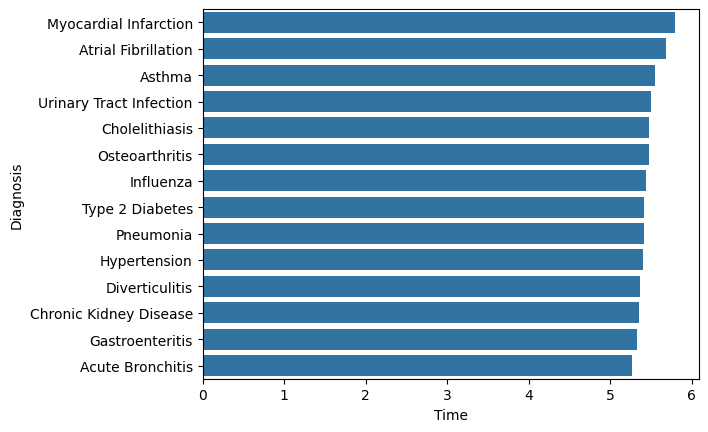

In [76]:
df['StayTime'] = (df['DischargeDate'] - df['AdmissionDate']).dt.days
df_stay_time = df[df['StayTime'] > 0]
stay_time = df_stay_time.groupby('Diagnosis').agg(
    Time = ('StayTime', 'mean')
)
total_stay_time = stay_time.sort_values(by='Time', ascending = False).reset_index()
total_stay_time
sns.barplot(data=total_stay_time, x = 'Time', y = 'Diagnosis')




## Average Stay Duration by Diagnosis

The dataset is grouped by diagnosis, and the average stay duration is calculated for each category.

This allows us to compare how long patients typically remain hospitalized depending on their diagnosis.

The average hospital stay across diagnoses is relatively uniform (≈5–6 days), suggesting limited variability in the dataset. This may indicate standardized discharge patterns or synthetic data generation, reducing the strength of diagnosis-based comparisons. We can see though that the highest average stay time is for Myocardial Infections.

##


## Top 10 Hospitals by Patient Volume

We group the dataset by hospital and count the number of patient records associated with each institution.

The hospitals are then ranked in descending order based on patient volume, and the top 10 are selected for visualization.

This approach ensures a clear and interpretable comparison by focusing only on the most significant contributors, avoiding clutter from less frequent categories.

<Axes: xlabel='PatientNumbers', ylabel='HospitalID'>

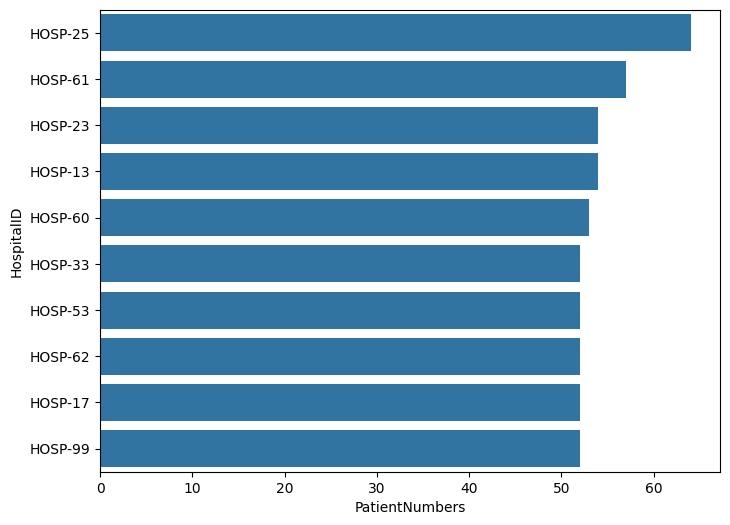

In [82]:
patients = df.groupby('HospitalID').agg(
    PatientNumbers = ('PatientID', 'count')
)
hospitals = patients.sort_values(by='PatientNumbers', ascending=False).reset_index()
top_hospitals = hospitals.head(10)
top_hospitals
fig, ax = plt.subplots(figsize = (8, 6))
sns.barplot(data = top_hospitals, x = 'PatientNumbers', y = 'HospitalID', order=top_hospitals['HospitalID'])


## Hospital-Level Analysis

The dataset contains a large number of unique hospitals, making full visualization impractical and difficult to interpret.

To improve clarity, only the top hospitals based on frequency (or relevant metric) are displayed. This approach highlights the most significant contributors while maintaining readability.

Less frequent hospitals are excluded from the visualization, as including all categories would reduce interpretability without adding meaningful insight.